<a href="https://colab.research.google.com/github/aditi-tawade-ai/SkillBuilding/blob/main/ML_Practice/Social_newtwork_class_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [57]:
path = '/content/Social_Net_class.csv'
s = pd.read_csv(path)
s[:3]

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0


In [58]:
s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [59]:
s.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [60]:
s.isna().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [61]:
s.Purchased.unique()

array([0, 1])

In [62]:
s.Gender.unique()

array(['Male', 'Female'], dtype=object)

In [63]:
gn = s['Gender'].replace({'Male':0,'Female':1})
s['Gender'] = gn
s[:5]

/tmp/ipykernel_621/390124432.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gn = s['Gender'].replace({'Male':0,'Female':1})


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,0,19,76000,0


In [64]:
X = s.iloc[:,:-1]
X[:2]

,User ID,Gender,Age,EstimatedSalary
0,15624510,0,19,19000
1,15810944,0,35,20000


In [65]:
y = s.iloc[:,4]
y[:2]

,Purchased
0,0
1,0


# Spliting the data

In [66]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [67]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
knn.score(X_train,y_train)*100

81.25

In [68]:
X_train[:5]

,User ID,Gender,Age,EstimatedSalary
230,15794253,1,35,147000
182,15694288,1,32,117000
212,15707596,1,59,42000
214,15622478,0,47,43000
279,15759684,1,50,36000


In [69]:
# testing data
y_pred = knn.predict(X_test)
y_pred

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1])

In [70]:
y_test.values

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1])

In [71]:
print('Accuracy is:',knn.score(X_test,y_test)*100)

Accuracy is: 78.75


we have got the Accuracy but we need confusion matrix to check the models score

In [72]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test,y_pred)
cm

array([[53,  3],
       [14, 10]])

Text(50.72222222222221, 0.5, 'Actual')

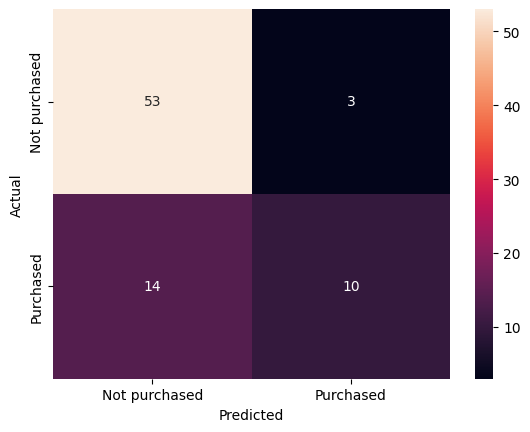

In [73]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True,
            xticklabels=['Not purchased','Purchased'],yticklabels=['Not purchased','Purchased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [74]:
#actual record of class 0
sum(y_test==0)

56

In [75]:
sum(y_pred==0)

np.int64(67)

In [76]:
sum(y_test==1)

24

In [77]:
sum(y_pred==1)

np.int64(13)

In [78]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.95      0.86        56
           1       0.77      0.42      0.54        24

    accuracy                           0.79        80
   macro avg       0.78      0.68      0.70        80
weighted avg       0.78      0.79      0.77        80



# Find the value of k using precision

In [79]:
from sklearn.metrics import precision_score,recall_score,f1_score

In [80]:
p_list = []
n_list=[]
for i in range(1,11):
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)

  p_list.append(precision_score(y_test,y_pred))
  n_list.append(i)

In [81]:
p_list

[0.64,
 0.8461538461538461,
 0.8,
 0.9,
 0.7692307692307693,
 0.8181818181818182,
 0.8333333333333334,
 0.9,
 0.9230769230769231,
 0.9090909090909091]

In [82]:
n_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Text(0.5, 1.0, 'precision score vs k value')

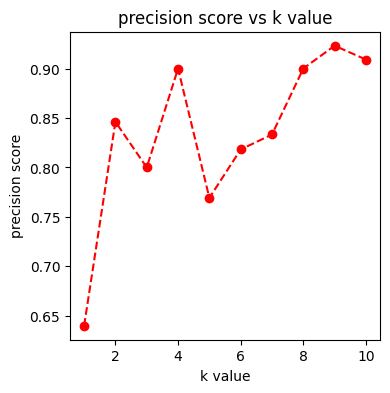

In [83]:
plt.figure(figsize=(4,4))
plt.plot(n_list,p_list,'r--o')
plt.xlabel('k value')
plt.ylabel('precision score')
plt.title('precision score vs k value')

# finding k using f1 score

In [84]:
f1_list = []
k_list = []
for k in range(1,11):
  clf = KNeighborsClassifier(n_neighbors=k)
  clf.fit(X_train,y_train)
  y_pred = clf.predict(X_test)
  f1_list.append(f1_score(y_test,y_pred))
  k_list.append(k)

In [85]:
k_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [86]:
print(f1_list)

[0.6530612244897959, 0.5945945945945946, 0.7272727272727273, 0.5294117647058824, 0.5405405405405406, 0.5142857142857142, 0.5555555555555556, 0.5294117647058824, 0.6486486486486487, 0.5714285714285714]


In [87]:
max(f1_list)

0.7272727272727273

In [88]:
f1_list.index(max(f1_list))

2

Text(0.5, 1.0, 'f1 score vs k value')

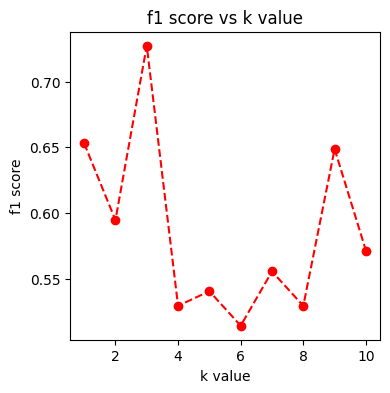

In [89]:
plt.figure(figsize=(4,4))
plt.plot(k_list,f1_list,'r--o')
plt.xlabel('k value')
plt.ylabel('f1 score')
plt.title('f1 score vs k value')


from above map we can see that the score is highest for the k value=2 so we choose neighbors=2

In [90]:
from sklearn.neighbors import KNeighborsClassifier
model_1 = KNeighborsClassifier(n_neighbors=5)
model_1.fit(X_train,y_train)
model_1.score(X_train,y_train)*100

81.25

# finding k value using recall score

In [98]:
c_list = []
i_list = []
for i in range(1,11):
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  c_list.append(recall_score(y_test,y_pred))
  i_list.append(i)


In [102]:
c_list

[0.6666666666666666,
 0.4583333333333333,
 0.6666666666666666,
 0.375,
 0.4166666666666667,
 0.375,
 0.4166666666666667,
 0.375,
 0.5,
 0.4166666666666667]

Text(0.5, 1.0, 'recall score vs k value')

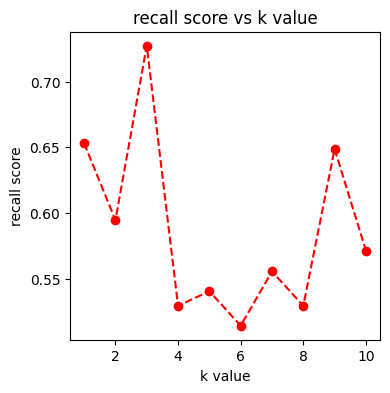

In [103]:
plt.figure(figsize=(4,4))
plt.plot(k_list,f1_list,'r--o')
plt.xlabel('k value')
plt.ylabel('recall score')
plt.title('recall score vs k value')

k = 2

# finding k value using error rate

In [92]:
y_test.values

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1])

In [93]:
error_rate = []
for i in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
print(error_rate)

[np.float64(0.2125), np.float64(0.1875), np.float64(0.15), np.float64(0.2), np.float64(0.2125), np.float64(0.2125), np.float64(0.2), np.float64(0.2), np.float64(0.1625), np.float64(0.1875)]


In [94]:
k_list

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [95]:
min(error_rate)

np.float64(0.15)

In [96]:
error_rate.index(min(error_rate))

2

Text(0.5, 1.0, 'error rate vs k value')

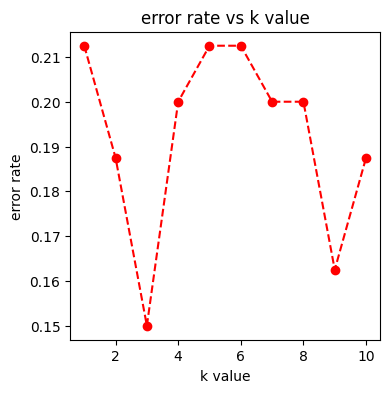

In [97]:
plt.figure(figsize=(4,4))
plt.plot(k_list,error_rate,'r--o')
plt.xlabel('k value')
plt.ylabel('error rate')
plt.title('error rate vs k value')

from above graph we can see error is minimum at 2

next import pkl file and save